In [1]:
# Q1

import cv2 as cv
import numpy as np

# Read image in grayscale
img = cv.imread(r'C:\Users\KAVINDU\OneDrive\Pictures\Screenshots\field image.png', cv.IMREAD_GRAYSCALE)

# Apply Canny Edge Detection
edges = cv.Canny(img, 550, 690)

# Resize images (width, height)
img_resized = cv.resize(img, (500, 400))
edges_resized = cv.resize(edges, (500, 400))

cv.imshow('Original Image (Resized)', img_resized)
cv.imshow('Canny Edge Image (Resized)', edges_resized)

cv.waitKey(0)
cv.destroyAllWindows()

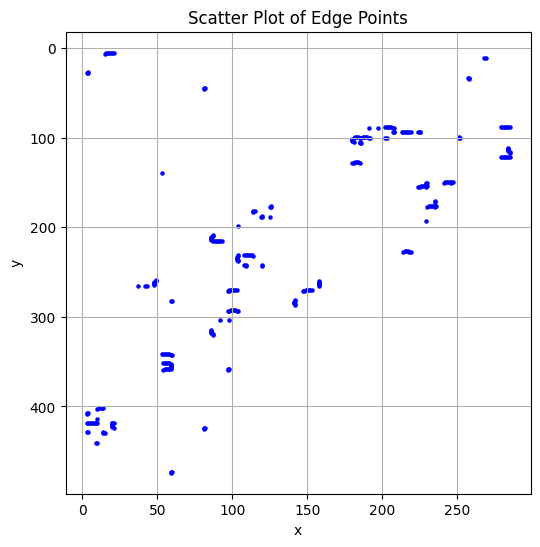

In [ ]:
# Q2: Extract points and scatter plot

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


edges = cv.Canny(img, 550, 690)

indices = np.where(edges != 0)
x = indices[1]
y = indices[0]
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='blue')
plt.title('Scatter Plot of Edge Points')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

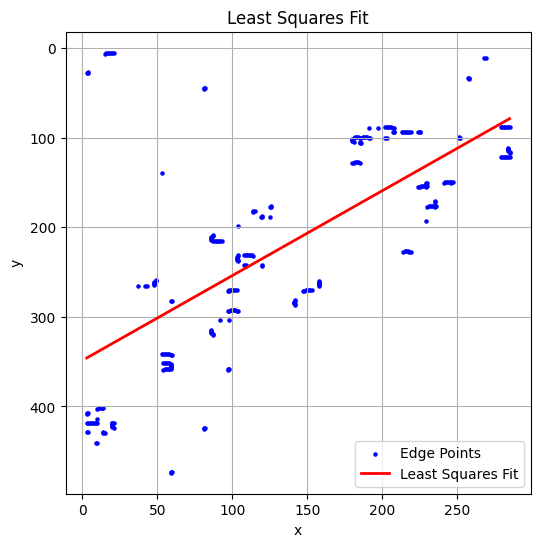

Least Squares slope (m) = -0.9473672627127137
Least Squares intercept (c) = 348.6824428772044


In [ ]:
#Q3
m_lsf, c_lsf = np.polyfit(x, y, 1)

x_line = np.linspace(np.min(x), np.max(x), 500)
y_line_lsf = m_lsf * x_line + c_lsf

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='blue', label='Edge Points')
plt.plot(x_line, y_line_lsf, 'r', linewidth=2, label='Least Squares Fit')
plt.title('Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

print("Least Squares slope (m) =", m_lsf)
print("Least Squares intercept (c) =", c_lsf)

In [9]:
m, c = np.polyfit(x, y, 1)

theta = np.degrees(np.arctan(m))
print(f"Estimated Angle (Least Squares): {theta:.2f} degrees")

Estimated Angle (Least Squares): -43.45 degrees


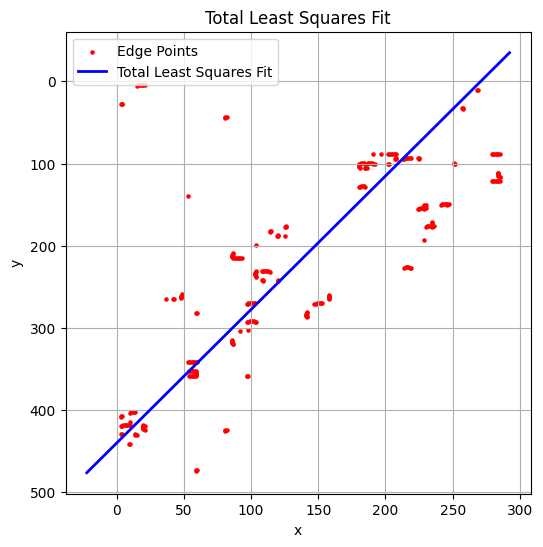

In [13]:
#Q6
points = np.column_stack((x, y))

mean = np.mean(points, axis=0)

centered = points - mean

cov = np.cov(centered.T)

eigenvalues, eigenvectors = np.linalg.eig(cov)

direction = eigenvectors[:, np.argmax(eigenvalues)]

dx, dy = direction[0], direction[1]

t = np.linspace(-300, 300, 500)
x_tls = mean[0] + t * dx
y_tls = mean[1] + t * dy

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, c='red', label='Edge Points')
plt.plot(x_tls, y_tls, 'b', linewidth=2, label='Total Least Squares Fit')
plt.title('Total Least Squares Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

In [14]:
theta_tls = np.degrees(np.arctan2(dy, dx))
print("Estimated crop field angle using Total Least Squares Fit =", theta_tls, "degrees")

Estimated crop field angle using Total Least Squares Fit = -58.401622265404214 degrees


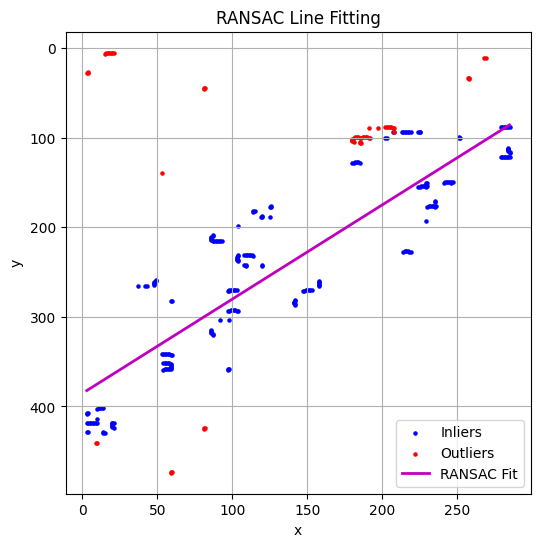

RANSAC slope = -1.0520161892280302
RANSAC intercept = 385.4193033687658


In [21]:
#Q10
from sklearn.linear_model import RANSACRegressor, LinearRegression
X = x.reshape(-1, 1)
Y = y

ransac = RANSACRegressor(estimator=LinearRegression(), random_state=0)
ransac.fit(X, Y)

y_ransac = ransac.predict(x_line.reshape(-1, 1))

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x[inlier_mask], y[inlier_mask], s=5, c='blue', label='Inliers')
plt.scatter(x[outlier_mask], y[outlier_mask], s=5, c='red', label='Outliers')
plt.plot(x_line, y_ransac, 'm', linewidth=2, label='RANSAC Fit')
plt.title('RANSAC Line Fitting')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

print("RANSAC slope =", m_ransac)
print("RANSAC intercept =", c_ransac)